# Temporal holdout — train Jul+Aug, test September (`future_transfer`)

Same full-domain recipe as `full_domain` (800×800, 12 levels 15–195 m, high_weight=0,
non-negativity kept, ~1.6 M params) but trained **only on the July + August episodes**
and evaluated on the **held-out September episode**. September is never seen in training.

The full September episode contains an anomalous near-surface event on **7 Sep** that
explodes the surface error; here we report the model on the first **three September days**
(4–6 Sep), a clean temporal-extrapolation test (train:test ≈ 192:72 h ≈ 73:27). Output:
pooled **RMSE** and pattern correlation **r** (per level and overall), then three example
snapshots — the best-correlated hour of each of the three days — in the paper composite
format (per-level **truth | prediction** with a shared colour scale, then the **relative
difference** map in % of truth).

In [1]:
import sys; sys.path.insert(0,'../../src')
import numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
from pathlib import Path
from dataloader import PALMDatasetV2
from model import UNet3DFiLM
OUT=Path('../../outputs'); device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ZH=[15,25,35,45,55,75,95,115,135,155,175,195]; NZ=12
CMAP='viridis'; WIDEN=0.0; RUN='future_transfer'
SEP='london_cm20190904-07'
# September episode, first 3 days = hours 1..71 = the three calendar days 4-6 Sep
hf={SEP:set(range(1,72))}
ck=torch.load(OUT/RUN/'checkpoints'/'best.pt',map_location='cpu',weights_only=False)
model=UNet3DFiLM(in_ch=18,spatial_ch=2,base_ch=16,dropout=0.0,n_z=NZ,use_attention=True,n_down=4)
model.load_state_dict(ck['model_state_dict']); model.to(device).eval()
st=ck['norm_stats']
ds=PALMDatasetV2(sims=[SEP],normalise=True,roi=None,hour_filter=hf,global_pm_norm=False,em_bg_norm=True,t_hist=1,z_range=(0,NZ)); ds._stats=st
mean=torch.tensor(st['pm25']['mean'][:NZ]).view(-1,1,1); std=torch.tensor(st['pm25']['std'][:NZ]).view(-1,1,1)
print('September (4-6 Sep) test snapshots:',len(ds))

September (4-6 Sep) test snapshots: 71


In [2]:
# per-layer + pooled performance (z0-11): RMSE and pattern correlation r
def pc(a,b):
    am=a-a.mean();bm=b-b.mean();d=np.sqrt((am**2).sum()*(bm**2).sum())
    return float((am*bm).sum()/d) if d>1e-9 else np.nan
agg={z:{'r':[],'p':[]} for z in range(NZ)}
ssr=np.zeros(NZ); cnt=np.zeros(NZ); snap_r=np.full(len(ds),np.nan)
with torch.no_grad():
    for i in range(len(ds)):
        x,y,mk=ds[i]; t=torch.expm1(y*std+mean).numpy(); msk=mk.numpy().astype(bool)
        p=torch.expm1(model(x.unsqueeze(0).to(device)).cpu()[0]*std+mean).numpy()
        rs=[]
        for z in range(NZ):
            s=msk[z]; a=t[z][s].astype(np.float64); b=p[z][s].astype(np.float64)
            if a.size<10 or a.std()<1e-6: continue
            ssr[z]+=((b-a)**2).sum(); cnt[z]+=a.size
            agg[z]['r'].append(np.sqrt(np.mean((b-a)**2))); r=pc(a,b); agg[z]['p'].append(r); rs.append(r)
        snap_r[i]=np.mean(rs) if rs else np.nan
mn=lambda l:np.mean(l) if l else np.nan
print(f'{"height":>8}{"RMSE":>9}{"r":>8}   (train Jul+Aug, test Sep 4-6)')
print('-'*32)
for z in range(NZ):
    a=agg[z]; print(f'{ZH[z]:>6}m {mn(a["r"]):>9.3f}{mn(a["p"]):>8.3f}')
PP=[x for z in range(NZ) for x in agg[z]['p']]
print(f'\nz0-11 OVERALL:  pooled RMSE {np.sqrt(ssr.sum()/cnt.sum()):.3f}   mean r {np.mean(PP):.3f}')
# pick the best-r hour of each of the three days as example cases
dates=[ds._index[i][4].strftime('%m-%d') for i in range(len(ds))]
CASES=[]
for d in sorted(set(dates)):
    idxs=[i for i in range(len(ds)) if dates[i]==d]
    bi=max(idxs,key=lambda i: (snap_r[i] if not np.isnan(snap_r[i]) else -9))
    ts=ds._index[bi][4]
    CASES.append((bi,f'idx{bi}  {ts.strftime("%-d %b %Y %H:%M")}  (r={snap_r[bi]:.2f})'))
print('\nexample cases (best hour per day):')
for c in CASES: print('  ',c[1])

  height     RMSE       r   (train Jul+Aug, test Sep 4-6)
--------------------------------
    15m     4.048   0.806
    25m     2.843   0.846
    35m     1.823   0.904
    45m     1.378   0.904
    55m     1.053   0.885
    75m     0.748   0.819
    95m     0.593   0.758
   115m     0.513   0.704
   135m     0.444   0.690
   155m     0.363   0.641
   175m     0.291   0.625
   195m     0.254   0.613

z0-11 OVERALL:  pooled RMSE 1.068   mean r 0.766

example cases (best hour per day):
   idx5  4 Sep 2019 06:00  (r=0.94)
   idx45  5 Sep 2019 22:00  (r=0.91)
   idx49  6 Sep 2019 02:00  (r=0.95)


In [3]:
# per level: truth | prediction | relative error (%). 2 levels per row -> 6 panels per row.
def plot_case(si):
    x,y,mk=ds[si]; mask=mk.numpy().astype(bool)
    with torch.no_grad(): out=model(x.unsqueeze(0).to(device)).cpu()[0]
    truth=torch.expm1(y*std+mean).numpy(); pred=torch.expm1(out*std+mean).numpy()
    rel=100.0*(pred-truth)/np.where(truth>1e-6,truth,np.nan)
    levels=list(range(NZ)); npr=2; nrows=(len(levels)+npr-1)//npr
    wr=[]; blocks=[]; ci=0
    for L in range(npr):
        blocks.append((ci,ci+1,ci+2,ci+4,ci+5)); wr+=[1,1,0.06,0.16,1,0.06]; ci+=6
        if L<npr-1: wr+=[0.38]; ci+=1
    fig=plt.figure(figsize=(14,2.35*nrows))
    gs=GridSpec(nrows,len(wr),width_ratios=wr,wspace=0.05,hspace=0.28)
    for i,z in enumerate(levels):
        r=i//npr; L=i%npr; ct,cp,cc1,ce,cc2=blocks[L]
        axt=fig.add_subplot(gs[r,ct]); axp=fig.add_subplot(gs[r,cp]); axc1=fig.add_subplot(gs[r,cc1])
        axe=fig.add_subplot(gs[r,ce]); axc2=fig.add_subplot(gs[r,cc2])
        ti=np.where(mask[z],truth[z],np.nan); pi=np.where(mask[z],pred[z],np.nan); ei=np.where(mask[z],rel[z],np.nan)
        if mask[z].sum()>=10:
            a=truth[z][mask[z]]; b=pred[z][mask[z]]
            vmin=min(np.percentile(a,1),np.percentile(b,1)); vmax=max(np.percentile(a,99),np.percentile(b,99))
            if z>=5 and WIDEN>0: s=vmax-vmin; vmin-=WIDEN*s; vmax+=WIDEN*s
            el=np.nanpercentile(np.abs(ei),98)+1e-9
        else: vmin,vmax,el=0.0,1.0,1.0
        imt=axt.imshow(ti,cmap=CMAP,vmin=vmin,vmax=vmax,origin='lower')
        axp.imshow(pi,cmap=CMAP,vmin=vmin,vmax=vmax,origin='lower')
        ime=axe.imshow(ei,cmap='RdBu_r',vmin=-el,vmax=el,origin='lower')
        for ax in (axt,axp,axe): ax.set_xticks([]); ax.set_yticks([])
        axt.set_title(f'{ZH[z]}m truth',fontsize=9); axp.set_title(f'{ZH[z]}m pred',fontsize=9); axe.set_title(f'{ZH[z]}m diff',fontsize=9)
        plt.colorbar(imt,cax=axc1)
        cb=plt.colorbar(ime,cax=axc2); cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda v,p: f'{v:+.0f}%'))
        axc1.tick_params(labelsize=7.5); axc2.tick_params(labelsize=7.5)
    import os; os.makedirs('figs', exist_ok=True)
    fig.savefig(f'figs/{RUN}_idx{si}.png', dpi=300, bbox_inches='tight')
    plt.show()
print('ready')

ready


### Example 1 — 4 Sep (best hour of day 1)

idx5  4 Sep 2019 06:00  (r=0.94)


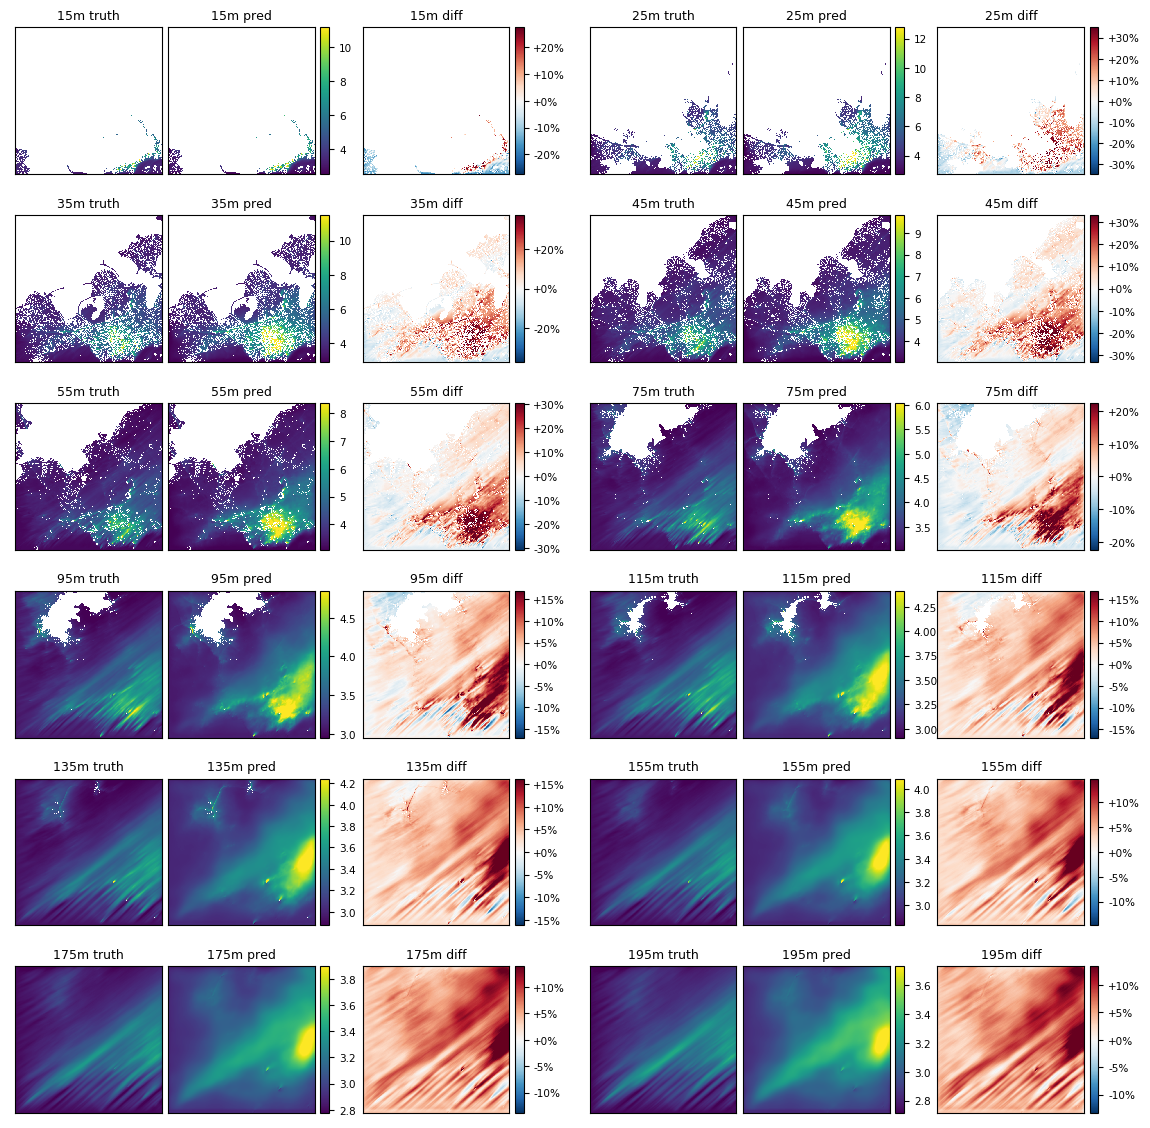

In [4]:
print(CASES[0][1]); plot_case(CASES[0][0])

### Example 2 — 5 Sep (best hour of day 2)

idx45  5 Sep 2019 22:00  (r=0.91)


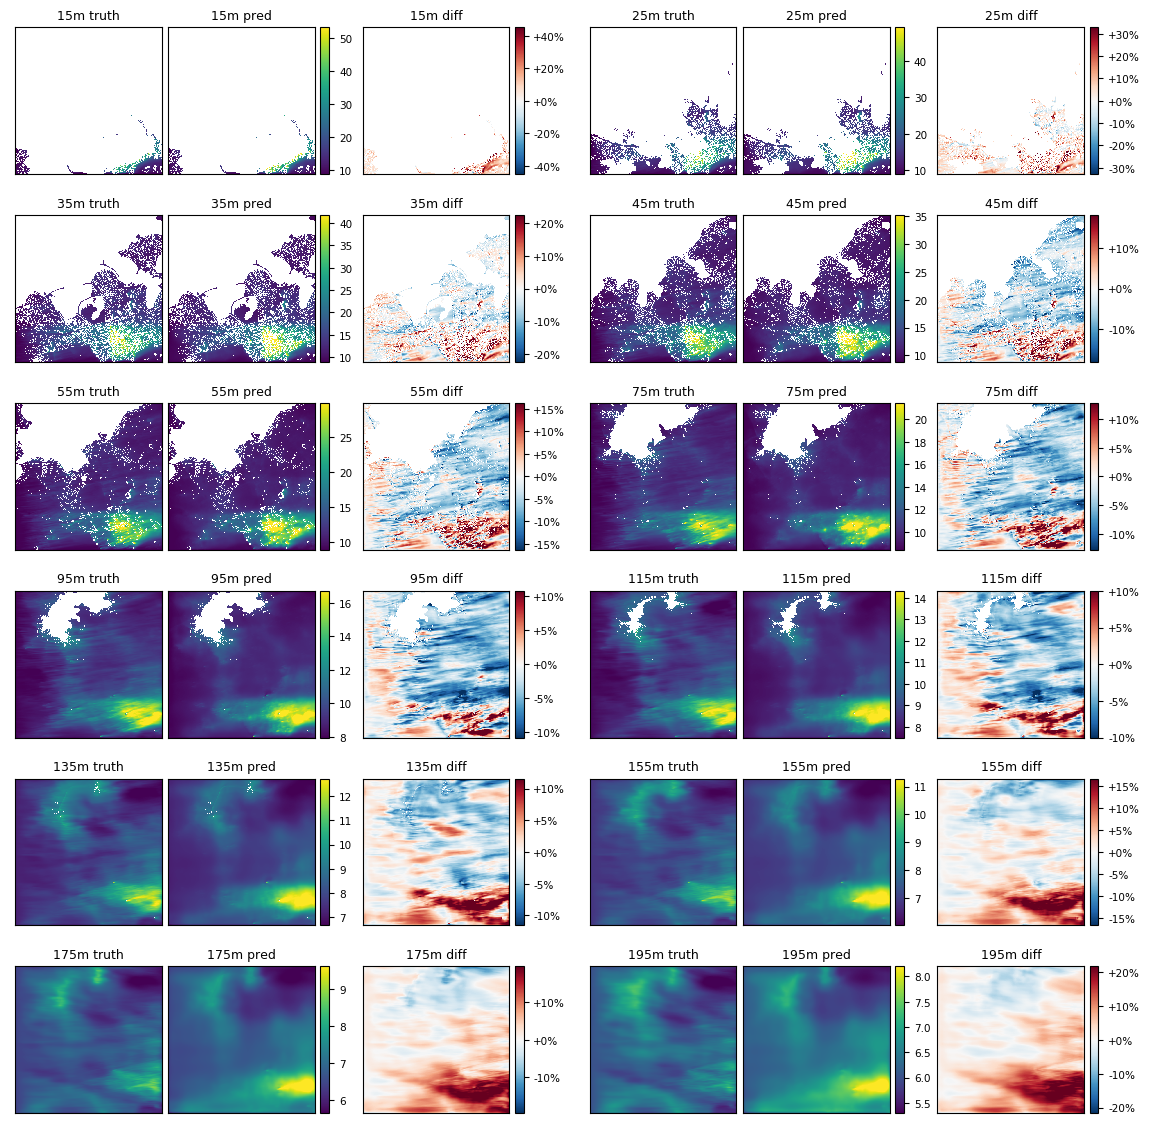

In [5]:
print(CASES[1][1]); plot_case(CASES[1][0])

### Example 3 — 6 Sep (best hour of day 3)

idx49  6 Sep 2019 02:00  (r=0.95)


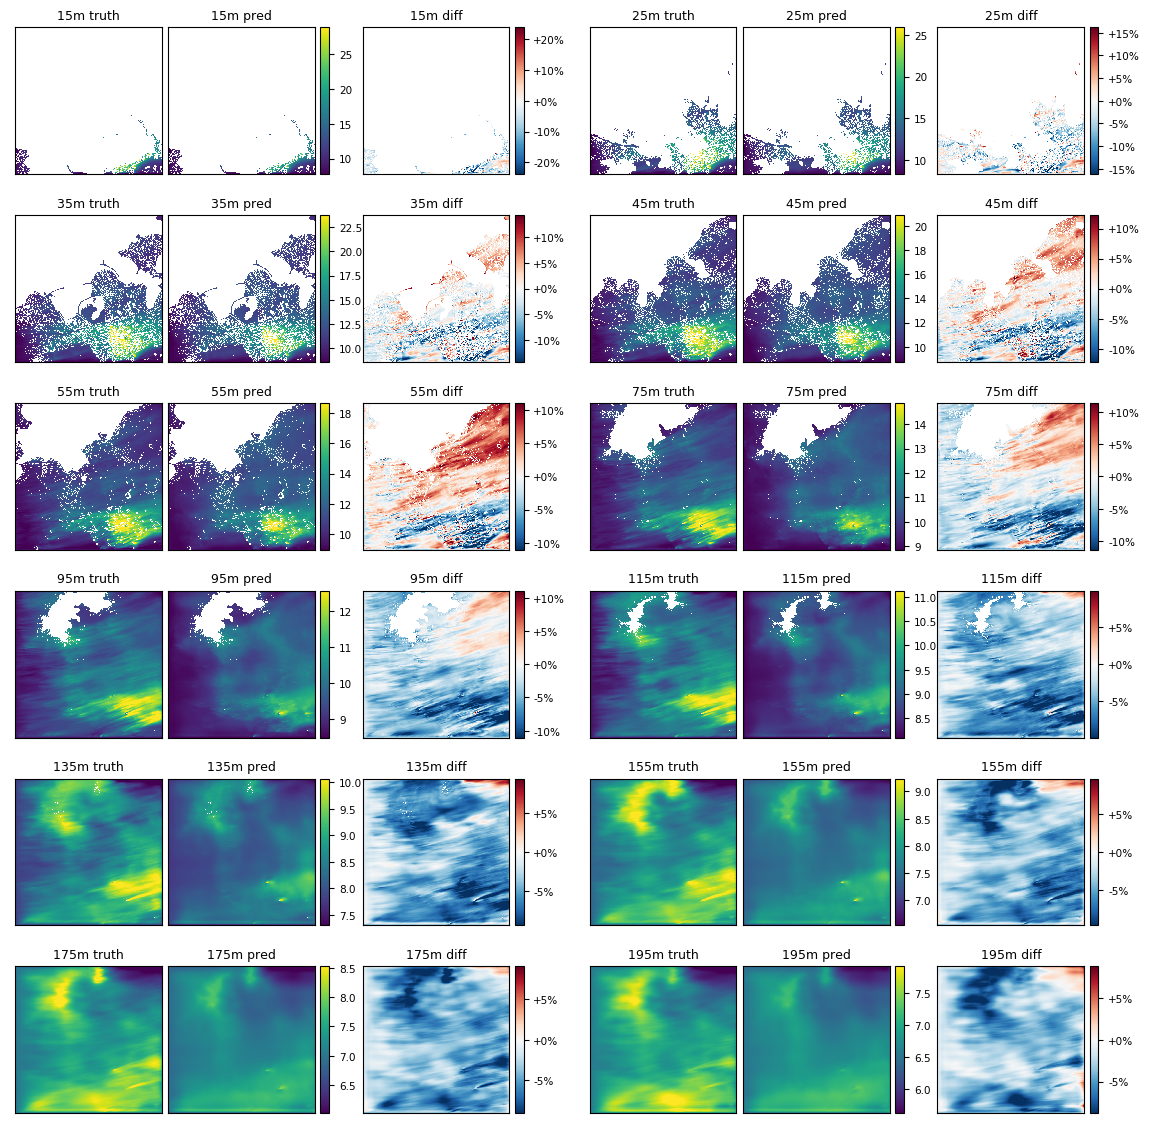

In [6]:
print(CASES[2][1]); plot_case(CASES[2][0])